In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 8: top-down hierarchical clustering

The goal of this problem is to write a function that implements divisive clustering (aka top-down hierarchical clustering).

Steps of Divisive Clustering:

- **Initialization:** Initially, all points in the dataset belong to one single cluster.
- **Step 1:** Select the cluster with the largest "sum of squared distances to its center".
- **Step 2:** Use kmeans to partition the selected cluster into two clusters.
- **Repeat** steps 1 and 2 until the desired number of clusters is obtained.

In [2]:
# kmeans function 
def kmeans(X,k,max_iterations=1000):
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0
    repeat = True
    
    # number of datapoints
    m = X.shape[0] 
    
    # initialization
    means = X[np.random.choice(m,k,replace=False)] 
    dist = pairwise_distances(X,means)
    clusters = np.argmin(dist, axis=1)
 
    
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no data points associated with it, replace it with a random data point
        means = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0
                          else  X[np.random.randint(m)]
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,means)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
                
        it += 1 # increment iteration counter by 1
    
    return clusters, means

In [6]:
# divisive_clustering function
def divisive_clustering(X,n_clusters=1):
    current_clusters = 1
    clusters = np.zeros(X.shape[0])
    means = [np.mean(X, axis = 0)]
    while(current_clusters < n_clusters):
        # find largest cluster
        distances = np.zeros(current_clusters)
        for i in range(current_clusters):
            distances[i] = np.sum(np.linalg.norm(X[clusters==i]-means[i])**2)
        largest = np.argmax(distances)
        #kmeans partition largest cluster
        newclust,newmean = kmeans(X[clusters==largest],k=2)
        newclust[newclust==1]= current_clusters
        newclust[newclust==0]=largest
        clusters[clusters==largest] = newclust
        means[largest]=newmean[0]
        means.append(newmean[1])
        current_clusters+=1
        
    return clusters, means

Test your function on the following toy dataset

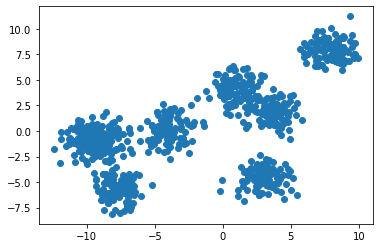

In [4]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=800,
                 centers = 8,
                 cluster_std=1,
                 random_state=3) 
plt.scatter(X[:,0],X[:,1])

In [7]:
clusters, means =divisive_clustering(X,n_clusters=7)

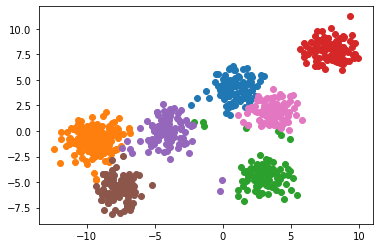

In [9]:
for i in range(7):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])

Is this good? I dont know. I don't like how the green cluster turned out here but I don't want to break my code :(